In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
import pandas as pd

from src.datasets.multi_season_dataset import build_multi_season_dataset
from src.preprocessing.preprocess import preprocess_train_test
from src.preprocessing.splits import split_raw_by_season
from src.evaluation.evaluate_classifier import evaluate_classifier, print_classifier_results


In [4]:
from src.feature_selection.feature_selector import FeatureSelector

raw_X, raw_y = build_multi_season_dataset(
    seasons=list(range(2003, 2026))
)

raw_X_train, raw_X_test, raw_y_train, raw_y_test = split_raw_by_season(
    raw_X,
    raw_y,
    test_seasons=[2025],
)

Starting season 2003...
Finished season 2003: 4616 rows built, 4616 raw games
Starting season 2004...
Finished season 2004: 4571 rows built, 4571 raw games
Starting season 2005...
Finished season 2005: 4675 rows built, 4675 raw games
Starting season 2006...
Finished season 2006: 4757 rows built, 4757 raw games
Starting season 2007...
Finished season 2007: 5043 rows built, 5043 raw games
Starting season 2008...
Finished season 2008: 5163 rows built, 5163 raw games
Starting season 2009...
Finished season 2009: 5249 rows built, 5249 raw games
Starting season 2010...
Finished season 2010: 5263 rows built, 5263 raw games
Starting season 2011...
Finished season 2011: 5246 rows built, 5246 raw games
Starting season 2012...
Finished season 2012: 5253 rows built, 5253 raw games
Starting season 2013...
Finished season 2013: 5320 rows built, 5320 raw games
Starting season 2014...
Finished season 2014: 5362 rows built, 5362 raw games
Starting season 2015...
Finished season 2015: 5354 rows built, 5

In [5]:
X_train, X_test, y_train, y_test = preprocess_train_test(
    raw_X_train,
    raw_X_test,
    raw_y_train,
    raw_y_test,
    prefix1="team_1_",
    prefix2="team_2_",
    invert_cols=["team_1_location"],
    diff_suffix="_diff",
    drop_base_features=True
)

selector = FeatureSelector()
K_FEATURES = 35

Processing Training Set:
--- Symmetrizing Dataset ---
Identified 58 base features to swap between team_1_ and team_2_:
['id', 'name', 'games_played', 'wins', 'losses', 'win_pct', 'ppg', 'papg', 'fg_pct', 'fg3_pct', 'ft_pct', 'off_rebounds_pg', 'def_rebounds_pg', 'assists_pg', 'turnovers_pg', 'steals_pg', 'blocks_pg', 'personal_fouls_pg', 'home_win_pct', 'away_win_pct', 'neutral_win_pct', 'last_5_games_played', 'last_5_win_pct', 'last_5_ppg', 'last_5_papg', 'last_5_fg_pct', 'last_5_fg3_pct', 'last_5_ft_pct', 'last_5_off_rebounds_pg', 'last_5_def_rebounds_pg', 'last_5_assists_pg', 'last_5_turnovers_pg', 'last_5_steals_pg', 'last_5_blocks_pg', 'last_5_personal_fouls_pg', 'last_10_games_played', 'last_10_win_pct', 'last_10_ppg', 'last_10_papg', 'last_10_fg_pct', 'last_10_fg3_pct', 'last_10_ft_pct', 'last_10_off_rebounds_pg', 'last_10_def_rebounds_pg', 'last_10_assists_pg', 'last_10_turnovers_pg', 'last_10_steals_pg', 'last_10_blocks_pg', 'last_10_personal_fouls_pg', 'current_win_streak', '

Subsampling 40000 rows from 226482 for Lasso speed...
--- Lasso (L1 Regularization Path) ---
Selected (35): ['last_5_assists_pg_diff', 'ft_attempt_rate_diff', 'personal_fouls_pg_diff', 'last_10_fg3_pct_diff', 'id_diff', 'current_loss_streak_diff', 'fg3_attempt_rate_diff', 'last_10_off_rebounds_pg_diff', 'neutral_win_pct_diff', 'last_10_def_rebounds_pg_diff', 'ft_pct_diff', 'turnover_to_assist_ratio_diff', 'games_played_diff', 'last_5_def_rebounds_pg_diff', 'last_10_ppg_diff', 'home_win_pct_diff', 'last_10_assists_pg_diff', 'last_5_off_rebounds_pg_diff', 'last_5_papg_diff', 'off_rebounds_pg_diff', 'last_10_blocks_pg_diff', 'assist_turnover_ratio_diff', 'steals_pg_diff', 'fg3_pct_diff', 'last_10_steals_pg_diff', 'assists_pg_diff', 'wins_diff', 'last_5_fg_pct_diff', 'last_10_papg_diff', 'ppg_diff', 'turnovers_pg_diff', 'losses_diff', 'win_pct_diff', 'point_diff_pg_diff', 'team_1_location']
Removed  (23): ['papg_diff', 'fg_pct_diff', 'def_rebounds_pg_diff', 'blocks_pg_diff', 'away_win_pct_

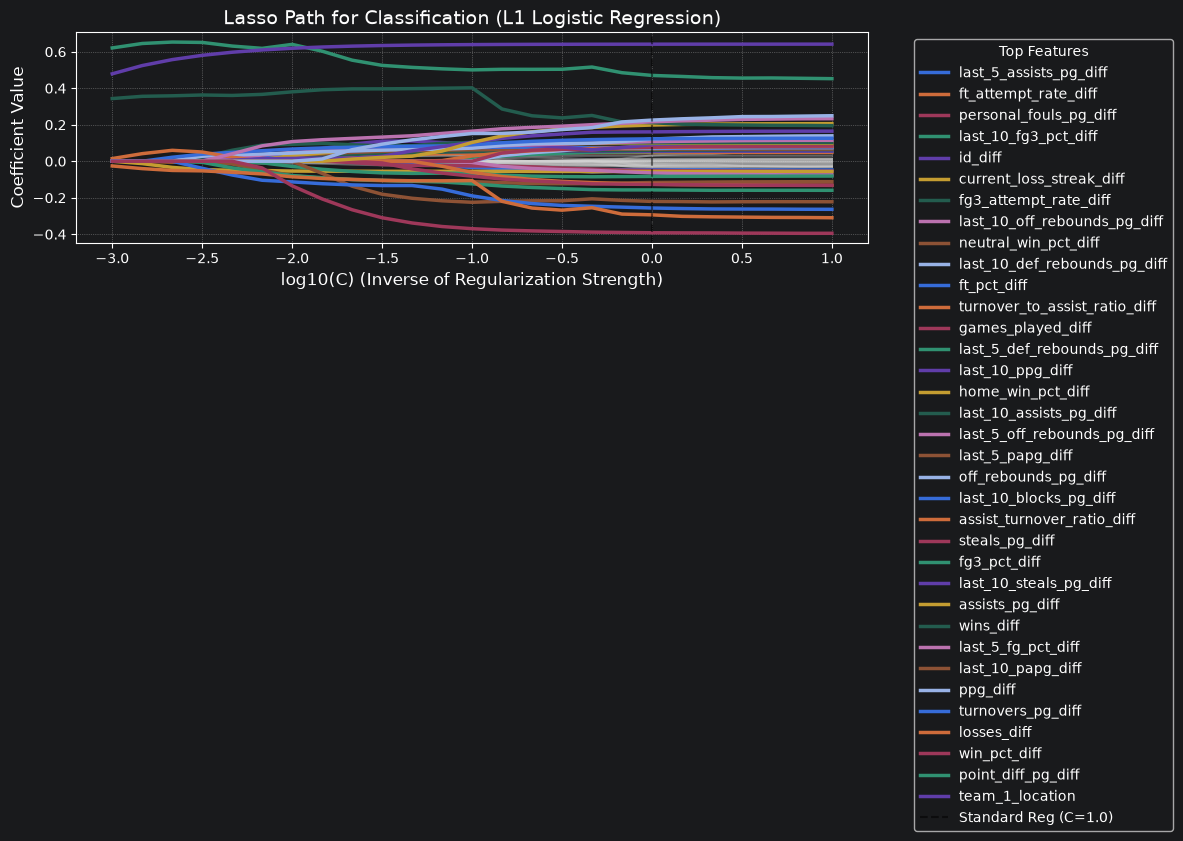

['last_5_assists_pg_diff',
 'ft_attempt_rate_diff',
 'personal_fouls_pg_diff',
 'last_10_fg3_pct_diff',
 'id_diff',
 'current_loss_streak_diff',
 'fg3_attempt_rate_diff',
 'last_10_off_rebounds_pg_diff',
 'neutral_win_pct_diff',
 'last_10_def_rebounds_pg_diff',
 'ft_pct_diff',
 'turnover_to_assist_ratio_diff',
 'games_played_diff',
 'last_5_def_rebounds_pg_diff',
 'last_10_ppg_diff',
 'home_win_pct_diff',
 'last_10_assists_pg_diff',
 'last_5_off_rebounds_pg_diff',
 'last_5_papg_diff',
 'off_rebounds_pg_diff',
 'last_10_blocks_pg_diff',
 'assist_turnover_ratio_diff',
 'steals_pg_diff',
 'fg3_pct_diff',
 'last_10_steals_pg_diff',
 'assists_pg_diff',
 'wins_diff',
 'last_5_fg_pct_diff',
 'last_10_papg_diff',
 'ppg_diff',
 'turnovers_pg_diff',
 'losses_diff',
 'win_pct_diff',
 'point_diff_pg_diff',
 'team_1_location']

In [6]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.linear_model")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.linear_model")
selector.run_lasso(X_train, y_train, target_features=K_FEATURES, print_results=True, plot_results=True)

--- Recursive Feature Elimination (Backward) ---
Selected (35): ['team_1_location', 'id_diff', 'games_played_diff', 'wins_diff', 'losses_diff', 'win_pct_diff', 'ppg_diff', 'papg_diff', 'fg_pct_diff', 'fg3_pct_diff', 'off_rebounds_pg_diff', 'assists_pg_diff', 'turnovers_pg_diff', 'home_win_pct_diff', 'neutral_win_pct_diff', 'last_5_win_pct_diff', 'last_5_ppg_diff', 'last_5_papg_diff', 'last_5_fg_pct_diff', 'last_5_ft_pct_diff', 'last_5_off_rebounds_pg_diff', 'last_5_turnovers_pg_diff', 'last_5_steals_pg_diff', 'last_10_win_pct_diff', 'last_10_ppg_diff', 'last_10_papg_diff', 'last_10_def_rebounds_pg_diff', 'last_10_assists_pg_diff', 'last_10_blocks_pg_diff', 'current_win_streak_diff', 'current_loss_streak_diff', 'point_diff_pg_diff', 'assist_turnover_ratio_diff', 'fg3_attempt_rate_diff', 'ft_attempt_rate_diff']
Removed  (23): ['ft_pct_diff', 'def_rebounds_pg_diff', 'steals_pg_diff', 'blocks_pg_diff', 'personal_fouls_pg_diff', 'away_win_pct_diff', 'last_5_games_played_diff', 'last_5_fg3_p

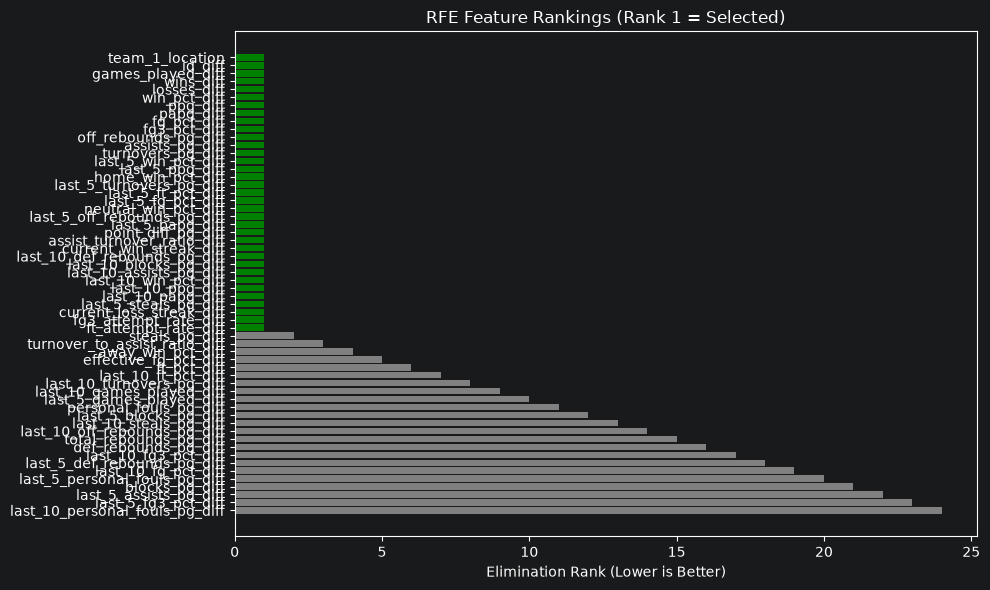

['team_1_location',
 'id_diff',
 'games_played_diff',
 'wins_diff',
 'losses_diff',
 'win_pct_diff',
 'ppg_diff',
 'papg_diff',
 'fg_pct_diff',
 'fg3_pct_diff',
 'off_rebounds_pg_diff',
 'assists_pg_diff',
 'turnovers_pg_diff',
 'home_win_pct_diff',
 'neutral_win_pct_diff',
 'last_5_win_pct_diff',
 'last_5_ppg_diff',
 'last_5_papg_diff',
 'last_5_fg_pct_diff',
 'last_5_ft_pct_diff',
 'last_5_off_rebounds_pg_diff',
 'last_5_turnovers_pg_diff',
 'last_5_steals_pg_diff',
 'last_10_win_pct_diff',
 'last_10_ppg_diff',
 'last_10_papg_diff',
 'last_10_def_rebounds_pg_diff',
 'last_10_assists_pg_diff',
 'last_10_blocks_pg_diff',
 'current_win_streak_diff',
 'current_loss_streak_diff',
 'point_diff_pg_diff',
 'assist_turnover_ratio_diff',
 'fg3_attempt_rate_diff',
 'ft_attempt_rate_diff']

In [7]:
selector.run_rfe(X_train, y_train, target_features=K_FEATURES, print_results=True, plot_results=True)

--- Random Forest Importance ---
Selected (35): ['total_rebounds_pg_diff', 'personal_fouls_pg_diff', 'steals_pg_diff', 'last_10_ft_pct_diff', 'ft_pct_diff', 'turnovers_pg_diff', 'last_10_fg3_pct_diff', 'last_5_ppg_diff', 'off_rebounds_pg_diff', 'last_5_fg3_pct_diff', 'last_5_ft_pct_diff', 'blocks_pg_diff', 'fg3_pct_diff', 'assists_pg_diff', 'last_5_fg_pct_diff', 'ft_attempt_rate_diff', 'fg3_attempt_rate_diff', 'last_5_papg_diff', 'last_10_fg_pct_diff', 'last_10_ppg_diff', 'losses_diff', 'last_10_papg_diff', 'effective_fg_pct_diff', 'papg_diff', 'fg_pct_diff', 'ppg_diff', 'assist_turnover_ratio_diff', 'turnover_to_assist_ratio_diff', 'home_win_pct_diff', 'id_diff', 'last_10_win_pct_diff', 'wins_diff', 'win_pct_diff', 'team_1_location', 'point_diff_pg_diff']
Removed  (23): ['games_played_diff', 'def_rebounds_pg_diff', 'away_win_pct_diff', 'neutral_win_pct_diff', 'last_5_games_played_diff', 'last_5_win_pct_diff', 'last_5_off_rebounds_pg_diff', 'last_5_def_rebounds_pg_diff', 'last_5_assist

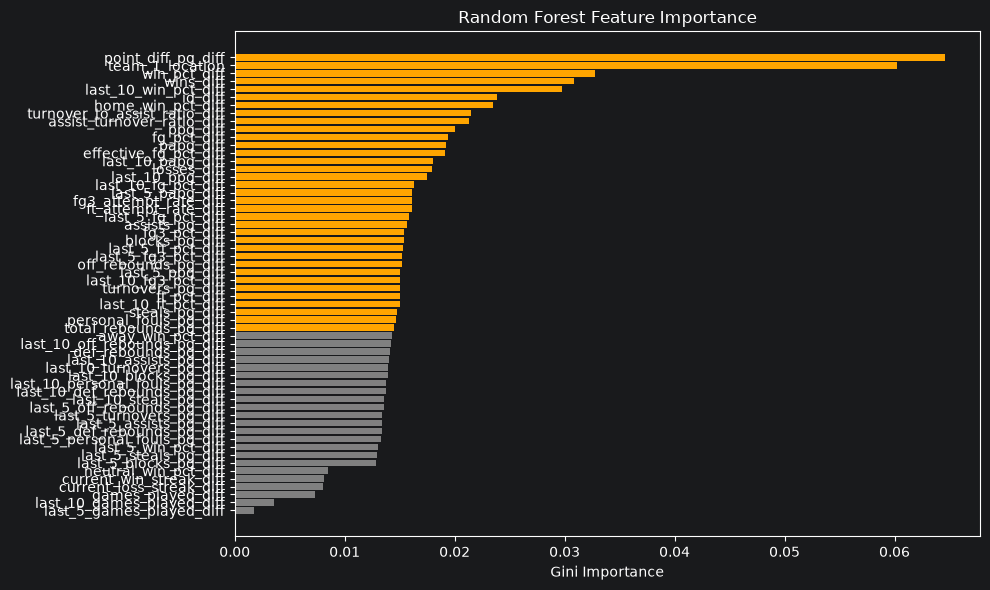

['total_rebounds_pg_diff',
 'personal_fouls_pg_diff',
 'steals_pg_diff',
 'last_10_ft_pct_diff',
 'ft_pct_diff',
 'turnovers_pg_diff',
 'last_10_fg3_pct_diff',
 'last_5_ppg_diff',
 'off_rebounds_pg_diff',
 'last_5_fg3_pct_diff',
 'last_5_ft_pct_diff',
 'blocks_pg_diff',
 'fg3_pct_diff',
 'assists_pg_diff',
 'last_5_fg_pct_diff',
 'ft_attempt_rate_diff',
 'fg3_attempt_rate_diff',
 'last_5_papg_diff',
 'last_10_fg_pct_diff',
 'last_10_ppg_diff',
 'losses_diff',
 'last_10_papg_diff',
 'effective_fg_pct_diff',
 'papg_diff',
 'fg_pct_diff',
 'ppg_diff',
 'assist_turnover_ratio_diff',
 'turnover_to_assist_ratio_diff',
 'home_win_pct_diff',
 'id_diff',
 'last_10_win_pct_diff',
 'wins_diff',
 'win_pct_diff',
 'team_1_location',
 'point_diff_pg_diff']

In [8]:
selector.run_tree_importance(X_train, y_train, target_features=K_FEATURES, print_results=True, plot_results=True)

In [9]:
selector.finalize_selection(vote_threshold=2, print_results=True)
X_train = selector.transform(X_train)
X_test = selector.transform(X_test)

FINAL FEATURE SELECTION VERDICT
Target Threshold: 2 votes required
Total Features Selected: 36

Detailed Voting Breakdown:
[KEEP] assist_turnover_ratio_diff: 3 vote(s)
[KEEP] assists_pg_diff: 3 vote(s)
[KEEP] fg3_attempt_rate_diff: 3 vote(s)
[KEEP] fg3_pct_diff: 3 vote(s)
[KEEP] ft_attempt_rate_diff: 3 vote(s)
[KEEP] home_win_pct_diff: 3 vote(s)
[KEEP] id_diff: 3 vote(s)
[KEEP] last_10_papg_diff: 3 vote(s)
[KEEP] last_10_ppg_diff: 3 vote(s)
[KEEP] last_5_fg_pct_diff: 3 vote(s)
[KEEP] last_5_papg_diff: 3 vote(s)
[KEEP] losses_diff: 3 vote(s)
[KEEP] off_rebounds_pg_diff: 3 vote(s)
[KEEP] point_diff_pg_diff: 3 vote(s)
[KEEP] ppg_diff: 3 vote(s)
[KEEP] team_1_location: 3 vote(s)
[KEEP] turnovers_pg_diff: 3 vote(s)
[KEEP] win_pct_diff: 3 vote(s)
[KEEP] wins_diff: 3 vote(s)
[KEEP] current_loss_streak_diff: 2 vote(s)
[KEEP] fg_pct_diff: 2 vote(s)
[KEEP] ft_pct_diff: 2 vote(s)
[KEEP] games_played_diff: 2 vote(s)
[KEEP] last_10_assists_pg_diff: 2 vote(s)
[KEEP] last_10_blocks_pg_diff: 2 vote(s)

Partitioning data to prevent leakage...
Training base learners...
logistic_l2          train=0.7199  test=0.7233
lightgbm             train=0.7279  test=0.7240
xgboost              train=0.7323  test=0.7247
random_forest        train=0.7596  test=0.7214
knn                  train=0.9959  test=0.6897
mlp                  train=0.7228  test=0.7219
Generating meta-features...
Training meta-learner...
Matrix 	ilde{E}^T * 	ilde{E} (Error Correlation):
[[1.     0.8865 0.8945 0.828  0.2093 0.9117]
 [0.8865 1.     0.9549 0.8804 0.2138 0.8797]
 [0.8945 0.9549 1.     0.8865 0.2158 0.8873]
 [0.828  0.8804 0.8865 1.     0.2378 0.833 ]
 [0.2093 0.2138 0.2158 0.2378 1.     0.211 ]
 [0.9117 0.8797 0.8873 0.833  0.211  1.    ]]


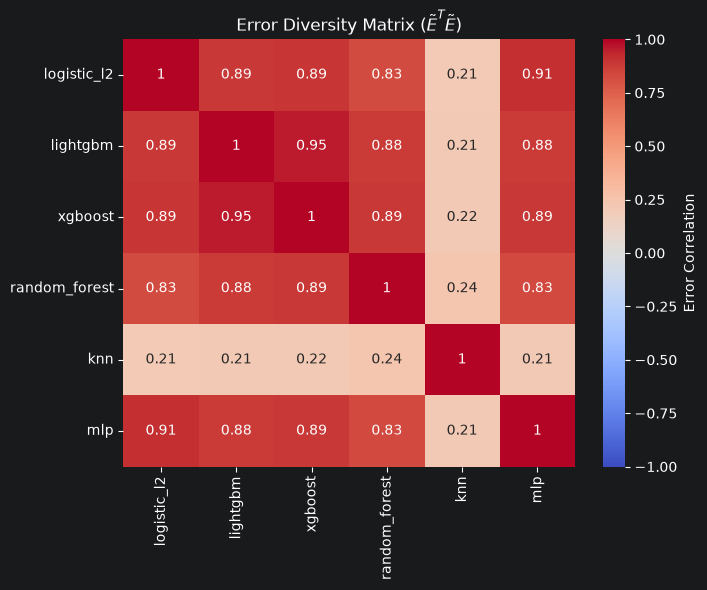

In [13]:
from src.predictors.predictors import EnsembleLearner
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier



model = EnsembleLearner(meta_test_size=0.15)

# 1. Add Logistic Regression (Add scaling and L2 regularization)
model.add_learner(
    "logistic_l2",
    Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(penalty='l2', C=0.1, solver='lbfgs', max_iter=1000))
    ])
)

# 2. Add LightGBM (The dominant algorithm for Men's data)
model.add_learner(
    "lightgbm",
    LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.02,
        max_depth=5,
        num_leaves=31,
        min_child_samples=40,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2.0,
        random_state=42,
        verbose=-1,
    )
)

# 3. Add XGBoost (Constrain depth to prevent memorization)
model.add_learner(
    "xgboost",
    XGBClassifier(
        n_estimators=800,
        learning_rate=0.01,
        max_depth=6,
        subsample=0.6,
        colsample_bytree=0.6,
        random_state=42,
    )
)


# 5. Add Random Forest
model.add_learner(
    "random_forest",
    RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_leaf=10,
        max_features="sqrt",
        bootstrap=True,
        random_state=42,
        n_jobs=-1,
    )
)

# 6. Add KNN classifier
model.add_learner(
    "knn",
    Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(
            n_neighbors=35,
            weights="distance",
            metric="minkowski",
            p=2,
        ))
    ])
)

# 7. Add Very Basic Neural Network
model.add_learner(
    "mlp",
    Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=300,
            early_stopping=True,
            random_state=42,
        ))
    ])
)

# Train the architecture
model.fit(X_train, y_train)
model.plot_error_heatmap(X_train, y_train)

# Generate Predictions
final_probabilities = model.predict_proba(X_test)
final_predictions = model.predict(X_test)

In [14]:
results = evaluate_classifier(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
)

print_classifier_results(results)

Classifier Evaluation
Train games     : 226,482
Test games      : 11,282

Train accuracy  : 73.26%
Test accuracy   : 71.35%

Train log loss  : 0.5272
Test log loss   : 0.5504

Train ROC-AUC   : 0.8142
Test ROC-AUC    : 0.7931

Train confusion matrix:
[[83144 30097]
 [30454 82787]]

Test confusion matrix:
[[4025 1616]
 [1616 4025]]
